

> **Tesla Deliveries Prediction Pipeline**

In this assignmnet, I am building an end-to-end machine learning pipeline using Tesla delivery data from 2015 to 2025.The goal is to predict estimated vehicle deliveries using production, pricing, battery, charging infrastructure and time based features.



In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Data Understanding

In this step, I checked the number of rows and columns, data types, summary statistics and whether any missing values were present.

In [59]:
df = pd.read_csv('/content/tesla_deliveries_dataset_2015_2025.csv')
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [61]:
print(df.shape)
df.info()
df.describe()
df.isnull().sum()

(2640, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


## Feature Engineering

Since this dataset contains time related information, I created a Date column and generated lag and rolling mean features. These features help the model learn from previous delivery patterns and capture short-term trends over time.

In [62]:
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' +df['Month'].astype(str) + '-01')
df = df.sort_values('Date')
df[['Year','Month','Date']].head()

,Year,Month,Date
872,2015,1,2015-01-01
2354,2015,1,2015-01-01
2312,2015,1,2015-01-01
2293,2015,1,2015-01-01
2215,2015,1,2015-01-01


In [63]:
df['Deliveries_Lag1'] = df['Estimated_Deliveries'].shift(1)
df['Rolling_Mean_3'] = (df['Estimated_Deliveries'].rolling(window=3).mean())
df[['Date','Estimated_Deliveries','Deliveries_Lag1','Rolling_Mean_3']].head(10)

,Date,Estimated_Deliveries,Deliveries_Lag1,Rolling_Mean_3
872,2015-01-01,12446,NaN,NaN
2354,2015-01-01,11446,12446.0,NaN
2312,2015-01-01,8803,11446.0,10898.333333
2293,2015-01-01,6367,8803.0,8872.000000
2215,2015-01-01,8795,6367.0,7988.333333
2065,2015-01-01,2161,8795.0,5774.333333
2023,2015-01-01,11986,2161.0,7647.333333
1872,2015-01-01,8833,11986.0,7660.000000
2469,2015-01-01,9446,8833.0,10088.333333
1766,2015-01-01,4350,9446.0,7543.000000


In [64]:
df = df.dropna()
df.shape

(2638, 15)

In [65]:
df_encoded = pd.get_dummies(df,columns=['Region', 'Model', 'Source_Type'],drop_first=True)
df_encoded.head()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Date,...,Rolling_Mean_3,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
2312,2015,1,8803,9344,102888.58,60,336,443.67,3923,2015-01-01,...,10898.333333,False,True,False,False,False,False,False,True,False
2293,2015,1,6367,6802,104962.32,82,459,438.37,9170,2015-01-01,...,8872.000000,False,False,True,False,False,False,False,False,False
2215,2015,1,8795,9165,87988.73,82,456,601.58,12626,2015-01-01,...,7988.333333,False,False,False,True,False,False,False,False,True
2065,2015,1,2161,2465,112637.91,120,695,225.28,14062,2015-01-01,...,5774.333333,True,False,False,False,False,False,False,False,False
2023,2015,1,11986,13302,91906.09,82,457,821.64,4871,2015-01-01,...,7647.333333,False,False,True,False,True,False,False,False,False


In [66]:
X = df_encoded.drop(['Estimated_Deliveries', 'Date'],axis=1)
y = df_encoded['Estimated_Deliveries']
print(X.shape)
print(y.shape)

(2638, 19)
(2638,)


In [67]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

(2110, 19)
(528, 19)


In [68]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Exploratory Data Analysis (EDA)

To better understand the data, I visualized relationships between important variables ,The following plots help identify trends, correlations and factors that may influence Tesla deliveries.

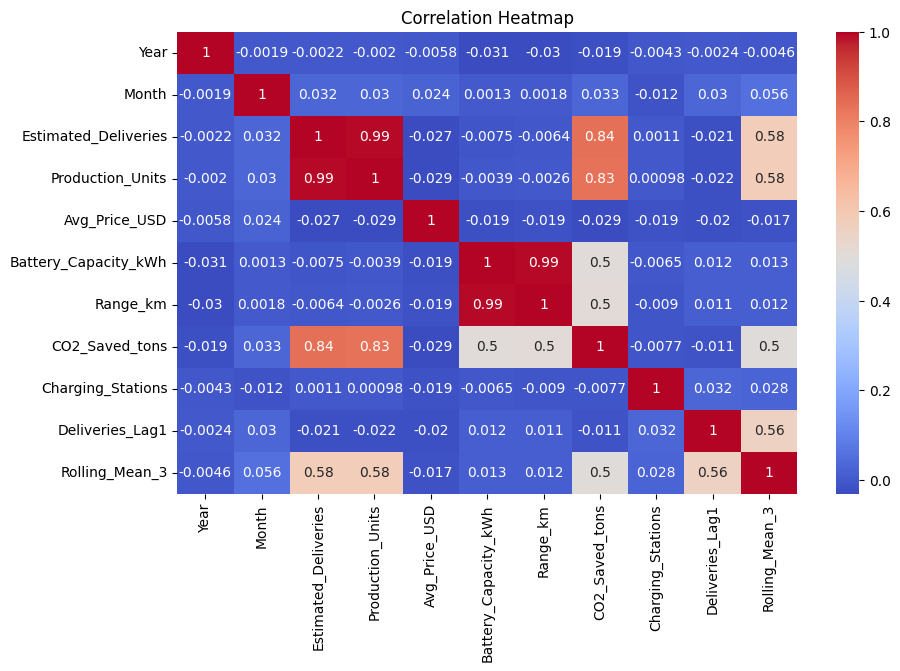

In [69]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True,cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

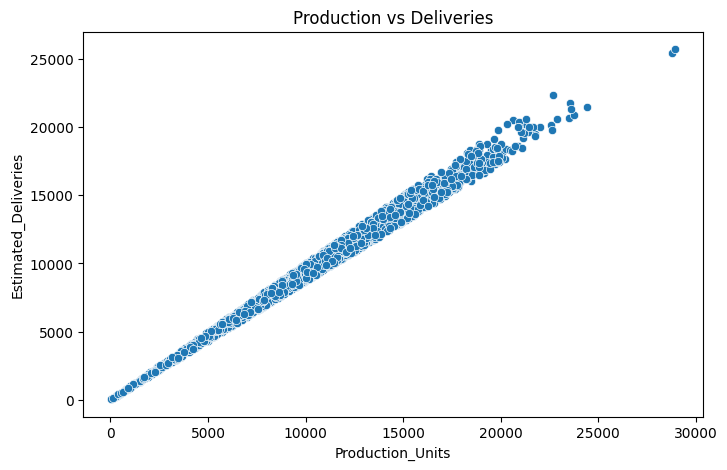

In [70]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Production_Units',y='Estimated_Deliveries',data=df)
plt.title('Production vs Deliveries')
plt.show()

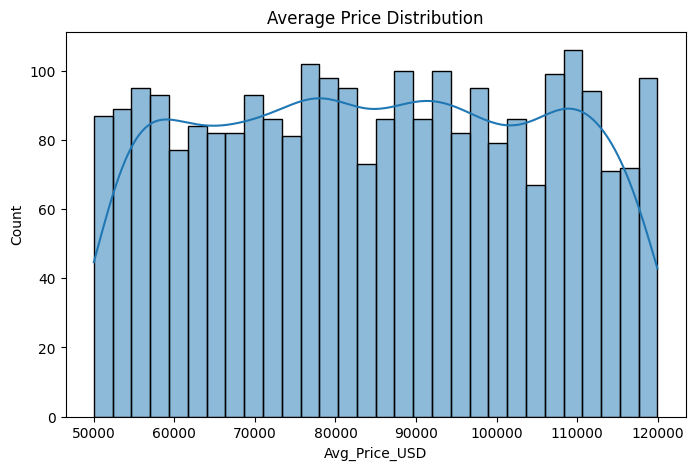

In [71]:
plt.figure(figsize=(8,5))
sns.histplot(df['Avg_Price_USD'],bins=30,kde=True)
plt.title('Average Price Distribution')
plt.show()

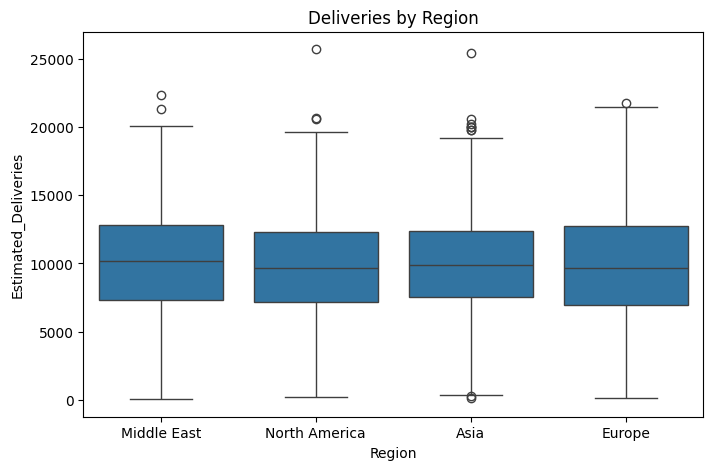

In [72]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Region',y='Estimated_Deliveries',data=df)
plt.title('Deliveries by Region')
plt.show()

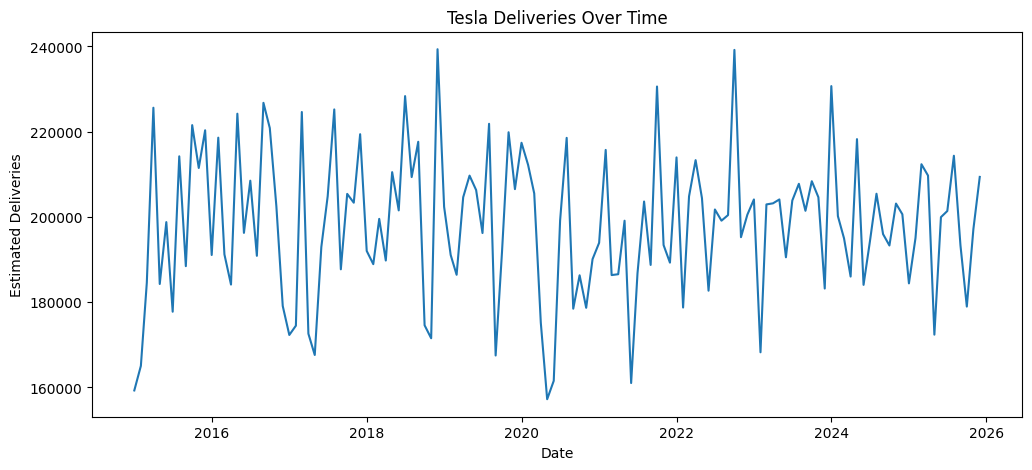

In [73]:
monthly_sales = (df.groupby('Date')['Estimated_Deliveries'].sum().reset_index())
plt.figure(figsize=(12,5))
plt.plot(monthly_sales['Date'],monthly_sales['Estimated_Deliveries'])
plt.title('Tesla Deliveries Over Time')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.show()

## Model Building and Hyperparameter Tuning

After preparing the dataset, I split it into training and testing sets and applied feature scaling. A Ridge Regression model was used for prediction, and GridSearchCV was applied to find the best alpha value for improved performance.

In [74]:
param_grid = {'alpha':[0.01,0.1,1,10,100]}
grid = GridSearchCV(Ridge(),param_grid,cv=5,scoring='r2')
grid.fit(X_train_scaled,y_train)
print("Best Alpha:",grid.best_params_)
print("Best CV Score:",grid.best_score_)

Best Alpha: {'alpha': 1}
Best CV Score: 0.9899656961482771


In [75]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_scaled)
print(y_pred[:10])

[ 4537.74033874  8074.844093   11026.48919174 10809.94028375
  5391.28264315  5580.45372036  9924.6497932   8310.39727164
  6138.92695174 14102.27959705]


In [76]:
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)
print("MAE:",mae)
print("RMSE:",rmse)
print("R2 Score:",r2)

MAE: 308.18083939857894
RMSE: 388.51088425301657
R2 Score: 0.9908673402884812


## Conclusion

An end-to-end machine learning pipeline was successfully built on Tesla delivery data.The workflow included data understanding, feature engineering, exploratory data analysis, model training, hyperparameter tuning and evaluation.
Time-series features such as lag values and rolling averages were incorporated into the model to capture historical delivery trends. The final model achieved strong predictive performance in estimating Tesla deliveries.

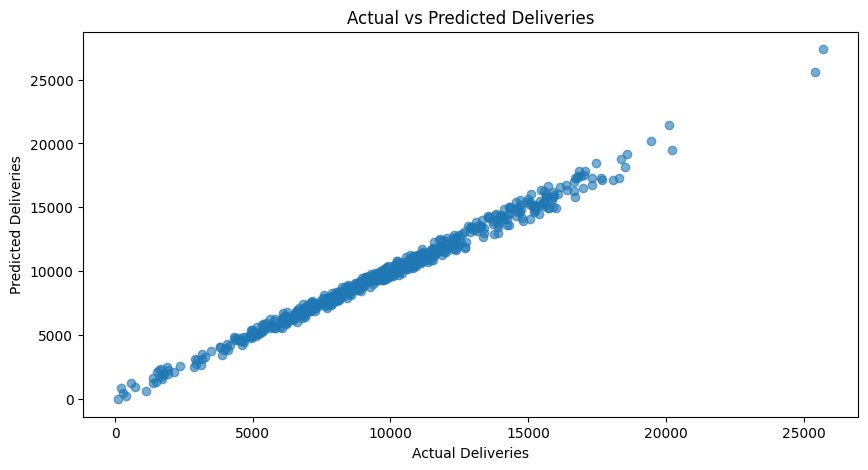

In [77]:
plt.figure(figsize=(10,5))
plt.scatter(y_test,y_pred,alpha=0.6)
plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title("Actual vs Predicted Deliveries")
plt.show()